In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)

### 1. Felsenstein's worst case with one shift

In [3]:
s1 = stree(100, type = "star")
s2 = stree(100, type = "star")
s1$tip.label = paste(s1$tip.label, "_1")
s2$tip.label = paste(s2$tip.label, "_2")
s1$edge.length = rep(1, length(s1$tip.label))
s2$edge.length = rep(1, length(s2$tip.label))

num_rep = 100
shifts = 10 ^ (seq(log10(1e-4), log10(1e4), len = 10))

n_rows = length(shifts) * num_rep * 4
p_vals_shift = data.table(
    shifts=character(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows)
)

divergence = .15
s1$root.edge = divergence
s2$root.edge = divergence

combined_tree = s1 + s2

PC1 = eigen(vcv(combined_tree))$vectors[,1]

counter = 1

for (i in 1:length(shifts)) {
    message(i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)
    
    for (j in 1:num_rep) {
        set.seed(j)
        
        BM = fastBM(combined_tree, 1, nsim = 2)
        X = BM[,1]
        Y = BM[,2]
        
        tree_1_tips = grep("_1", row.names(BM))
    
        X[tree_1_tips] = X[tree_1_tips] + rnorm(1, 0, sd = sqrt(shifts[i]))
        Y[tree_1_tips] = Y[tree_1_tips] + rnorm(1, 0, sd = sqrt(shifts[i]))
    
        all_data = as.data.frame(tibble(X = X, Y = Y, PC1 = PC1))
        rownames(all_data) = rownames(BM)
    
        cur_lm = lm(Y ~ X,data = all_data)
        cur_p = summary(cur_lm)$coefficients["X", "Pr(>|t|)"]
        p_vals_shift[counter, `:=`("shifts" = shift, "p.value" = cur_p,
                                   "method" = "lm")]

        counter = counter + 1
    
        cur_lm = lm(Y ~ X + PC1, data = all_data)
        cur_p = summary(cur_lm)$coefficients["X", "Pr(>|t|)"]
        p_vals_shift[counter, `:=`("shifts" = shift, "p.value" = cur_p,
                                   "method" = "lm_PC")]

        counter = counter + 1
     
        cur_lm = phylolm(Y ~ X, data = all_data, phy = combined_tree)
        cur_p = summary(cur_lm)$coefficients["X", "p.value"]
        p_vals_shift[counter, `:=`("shifts" = shift, "p.value" = cur_p,
                                   "method" = "phylolm")]

        counter = counter + 1
    
        cur_lm = phylolm(Y ~ X + PC1, data = all_data, phy = combined_tree)
        cur_p = summary(cur_lm)$coefficients["X", "p.value"]
        p_vals_shift[counter, `:=`("shifts" = shift, "p.value" = cur_p,
                                   "method" = "phylolm_PC")]

        counter = counter + 1
    
    }
  
}

1

2

3

4

5

6

7

8

9

10



In [55]:
shift_round = unique(p_vals_shift$shifts)

p_vals_qq <- p_vals_shift %>% filter(shifts == shift_round[8]) 
p_vals_qq_OLS_0 <- p_vals_qq %>% filter(method == "lm")
p_vals_qq_OLS_1 <- p_vals_qq %>% filter(method == "lm_PC")
p_vals_qq_PGLS_0 <- p_vals_qq %>% filter(method == "phylolm")
p_vals_qq_PGLS_1 <- p_vals_qq %>% filter(method == "phylolm_PC")

observed = c(sort(p_vals_qq_OLS_0$p.value), sort(p_vals_qq_PGLS_0$p.value))
expected = rep(ppoints(num_rep), 2)
method = rep(c("OLS", "PGLS"), each = num_rep)

qq_plot_df_1 <- data.frame(
    observed = -log10(observed), expected = -log10(expected), method = method
)

observed = c(sort(p_vals_qq_OLS_1$p.value), sort(p_vals_qq_PGLS_1$p.value))
expected = rep(ppoints(num_rep), 2)
method = rep(c("OLS", "PGLS"), each = num_rep)

qq_plot_df_2 <- data.frame(
    observed = -log10(observed), expected = -log10(expected), method = method
)


### 2. Yule tree with one shift

In [5]:
set.seed(19)
yule_tree = sim.bd.taxa(100, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 30
PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

shift = 1e4

num_rep = 100
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1
yule_tree_l = sum(yule_tree$edge.length)
probs = yule_tree$edge.length / yule_tree_l

n_rows = num_rep * length(PC_sets) * 4

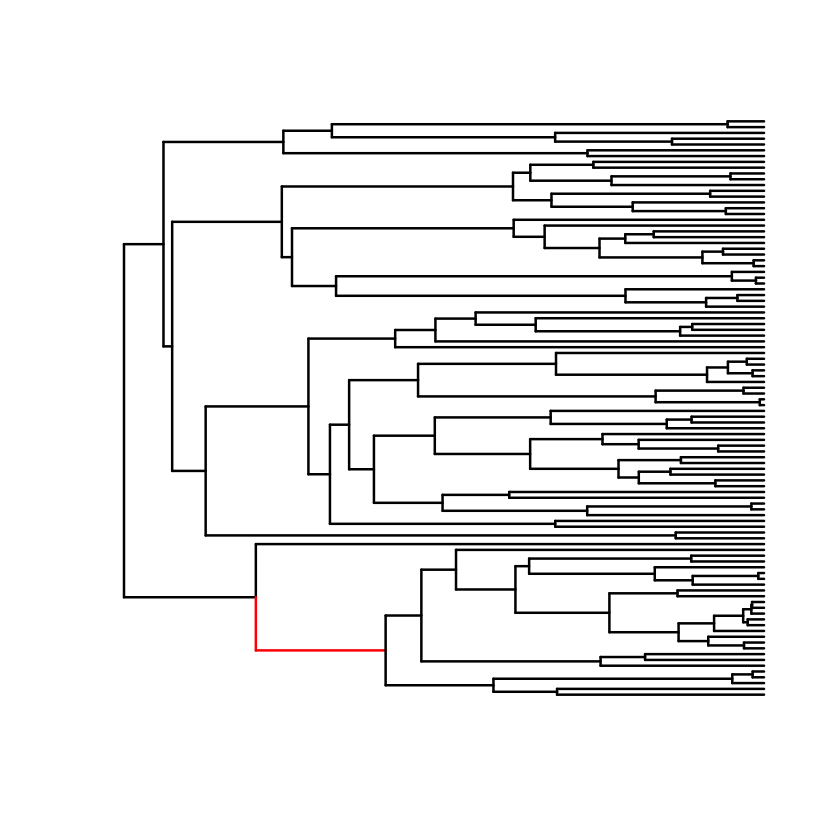

In [6]:
set.seed(19)
yule_tree = sim.bd.taxa(100, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

branch_colors = rep("black", each = 198)
branch_colors[2] = "red"

plot.phylo(yule_tree, edge.width = 2, edge.color = branch_colors, show.tip.label = FALSE)

In [78]:
p_vals_shift_2 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    method=character(n_rows)
)

k = 2
e = yule_tree$edge[k,]
descendants = getDescendants(yule_tree, e[2])
descendants_tips = descendants[descendants <= n_tips]

counter = 1
set.seed(19)

for (j in 1:num_rep) {
    if (j %% 10 == 0) {message(j)}
    BM = fastBM(yule_tree, 1, nsim=2)
    X = BM[,1]
    Y = BM[,2]
            
    X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
    Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
            
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    rownames(all_data) = rownames(BM)

    for (l in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))

        cur_lm = lm(cur_formula, data = all_data)
        cur_p = summary(cur_lm)$coefficients["X", "Pr(>|t|)"]
        p_vals_shift_2[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                     "method" = "lm")]

        counter = counter + 1

        cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
                    
        p_vals_shift_2[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,
                                     "method" = "phylolm")]

        counter = counter + 1
    }      
            
}

10

20

30

40

50

60

70

80

90

100



In [79]:
p_vals_qq_OLS_0 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 0)
p_vals_qq_OLS_5 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 5)
p_vals_qq_OLS_10 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 10)
p_vals_qq_OLS_15 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 15)
p_vals_qq_OLS_20 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 20)
p_vals_qq_OLS_21 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 21)
p_vals_qq_OLS_25 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 25)
p_vals_qq_OLS_30 <- p_vals_shift_2 %>% filter(method == "lm") %>% filter(PCs == 30)

p_vals_qq_PGLS_0 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 0)
p_vals_qq_PGLS_5 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 5)
p_vals_qq_PGLS_10 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 10)
p_vals_qq_PGLS_15 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 15)
p_vals_qq_PGLS_20 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 20)
p_vals_qq_PGLS_21 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 21)
p_vals_qq_PGLS_25 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 25)
p_vals_qq_PGLS_30 <- p_vals_shift_2 %>% filter(method == "phylolm") %>% filter(PCs == 30)

In [80]:
observed = c(sort(p_vals_qq_OLS_0$p.value), sort(p_vals_qq_OLS_5$p.value), 
             sort(p_vals_qq_OLS_10$p.value), sort(p_vals_qq_OLS_20$p.value), 
             sort(p_vals_qq_PGLS_0$p.value), sort(p_vals_qq_PGLS_5$p.value), 
             sort(p_vals_qq_PGLS_10$p.value), sort(p_vals_qq_PGLS_20$p.value))
expected = rep(ppoints(num_rep), 8)
method_full = rep(c("OLS", "OLS + 5 eigenvectors", "OLS + 10 eigenvectors", "OLS + 20 eigenvectors", 
               "PGLS", "PGLS + 5 eigenvectors", "PGLS + 10 eigenvectors", "PGLS + 20 eigenvectors"), 
             each = num_rep)
method = rep(c("OLS", "PGLS"), each = num_rep * 4)
eigenvectors = rep(c("0", "5", "10", "20", "0", "5", "10", "20"), each = num_rep)

qq_plot_df_5 <- data.frame(
    observed = -log10(observed), expected = -log10(expected), 
    method_full = method_full, method = method, eigenvectors = eigenvectors
)

In [81]:
observed = c(sort(p_vals_qq_OLS_30$p.value), sort(p_vals_qq_PGLS_30$p.value))
expected = rep(ppoints(num_rep), 2)
method = rep(c("OLS", "PGLS"), each = num_rep)

qq_plot_df_6 <- data.frame(
    observed = -log10(observed), expected = -log10(expected), method = method
)

In [100]:
qq_plot_1 <- qq_plot_df_1 %>% ggplot(aes(expected, observed, shape = method)) +
  geom_point(size = 2.3, color = "#4477AA") + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.09,.95),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_shape_manual(values = c(17, 19), 
                     breaks = c("OLS", "PGLS")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)

In [109]:
qq_plot_2 <- qq_plot_df_2 %>% ggplot(aes(expected, observed, shape = method)) +
  geom_point(size = 2.3, color = "#EE6677") + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.22,.95),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_shape_manual(values = c(17, 19), 
                     breaks = c("OLS", "PGLS")) +
  geom_abline(slope = 1, intercept = 0,lty = 2) + 
  labs(shape = "method + eigenvector 1")

In [110]:
qq_plot_3 <- qq_plot_df_5 %>% ggplot(aes(expected, observed, 
                                         shape = method, 
                                         color = eigenvectors)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.13,.85),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_color_manual(values = c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("0", "5", "10", "20")) + 
  scale_shape_manual(values = c(17, 19), 
                     breaks = c("OLS", "PGLS")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)

In [111]:
qq_plot_4 <- qq_plot_df_6 %>% ggplot(aes(expected, observed, shape = method)) +
  geom_point(size = 2.5, color = "#EE6677") + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.24,.95),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_shape_manual(values = c(17, 19), 
                     breaks = c("OLS", "PGLS")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2) + 
  labs(shape = "method + 30 eigenvectors")

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

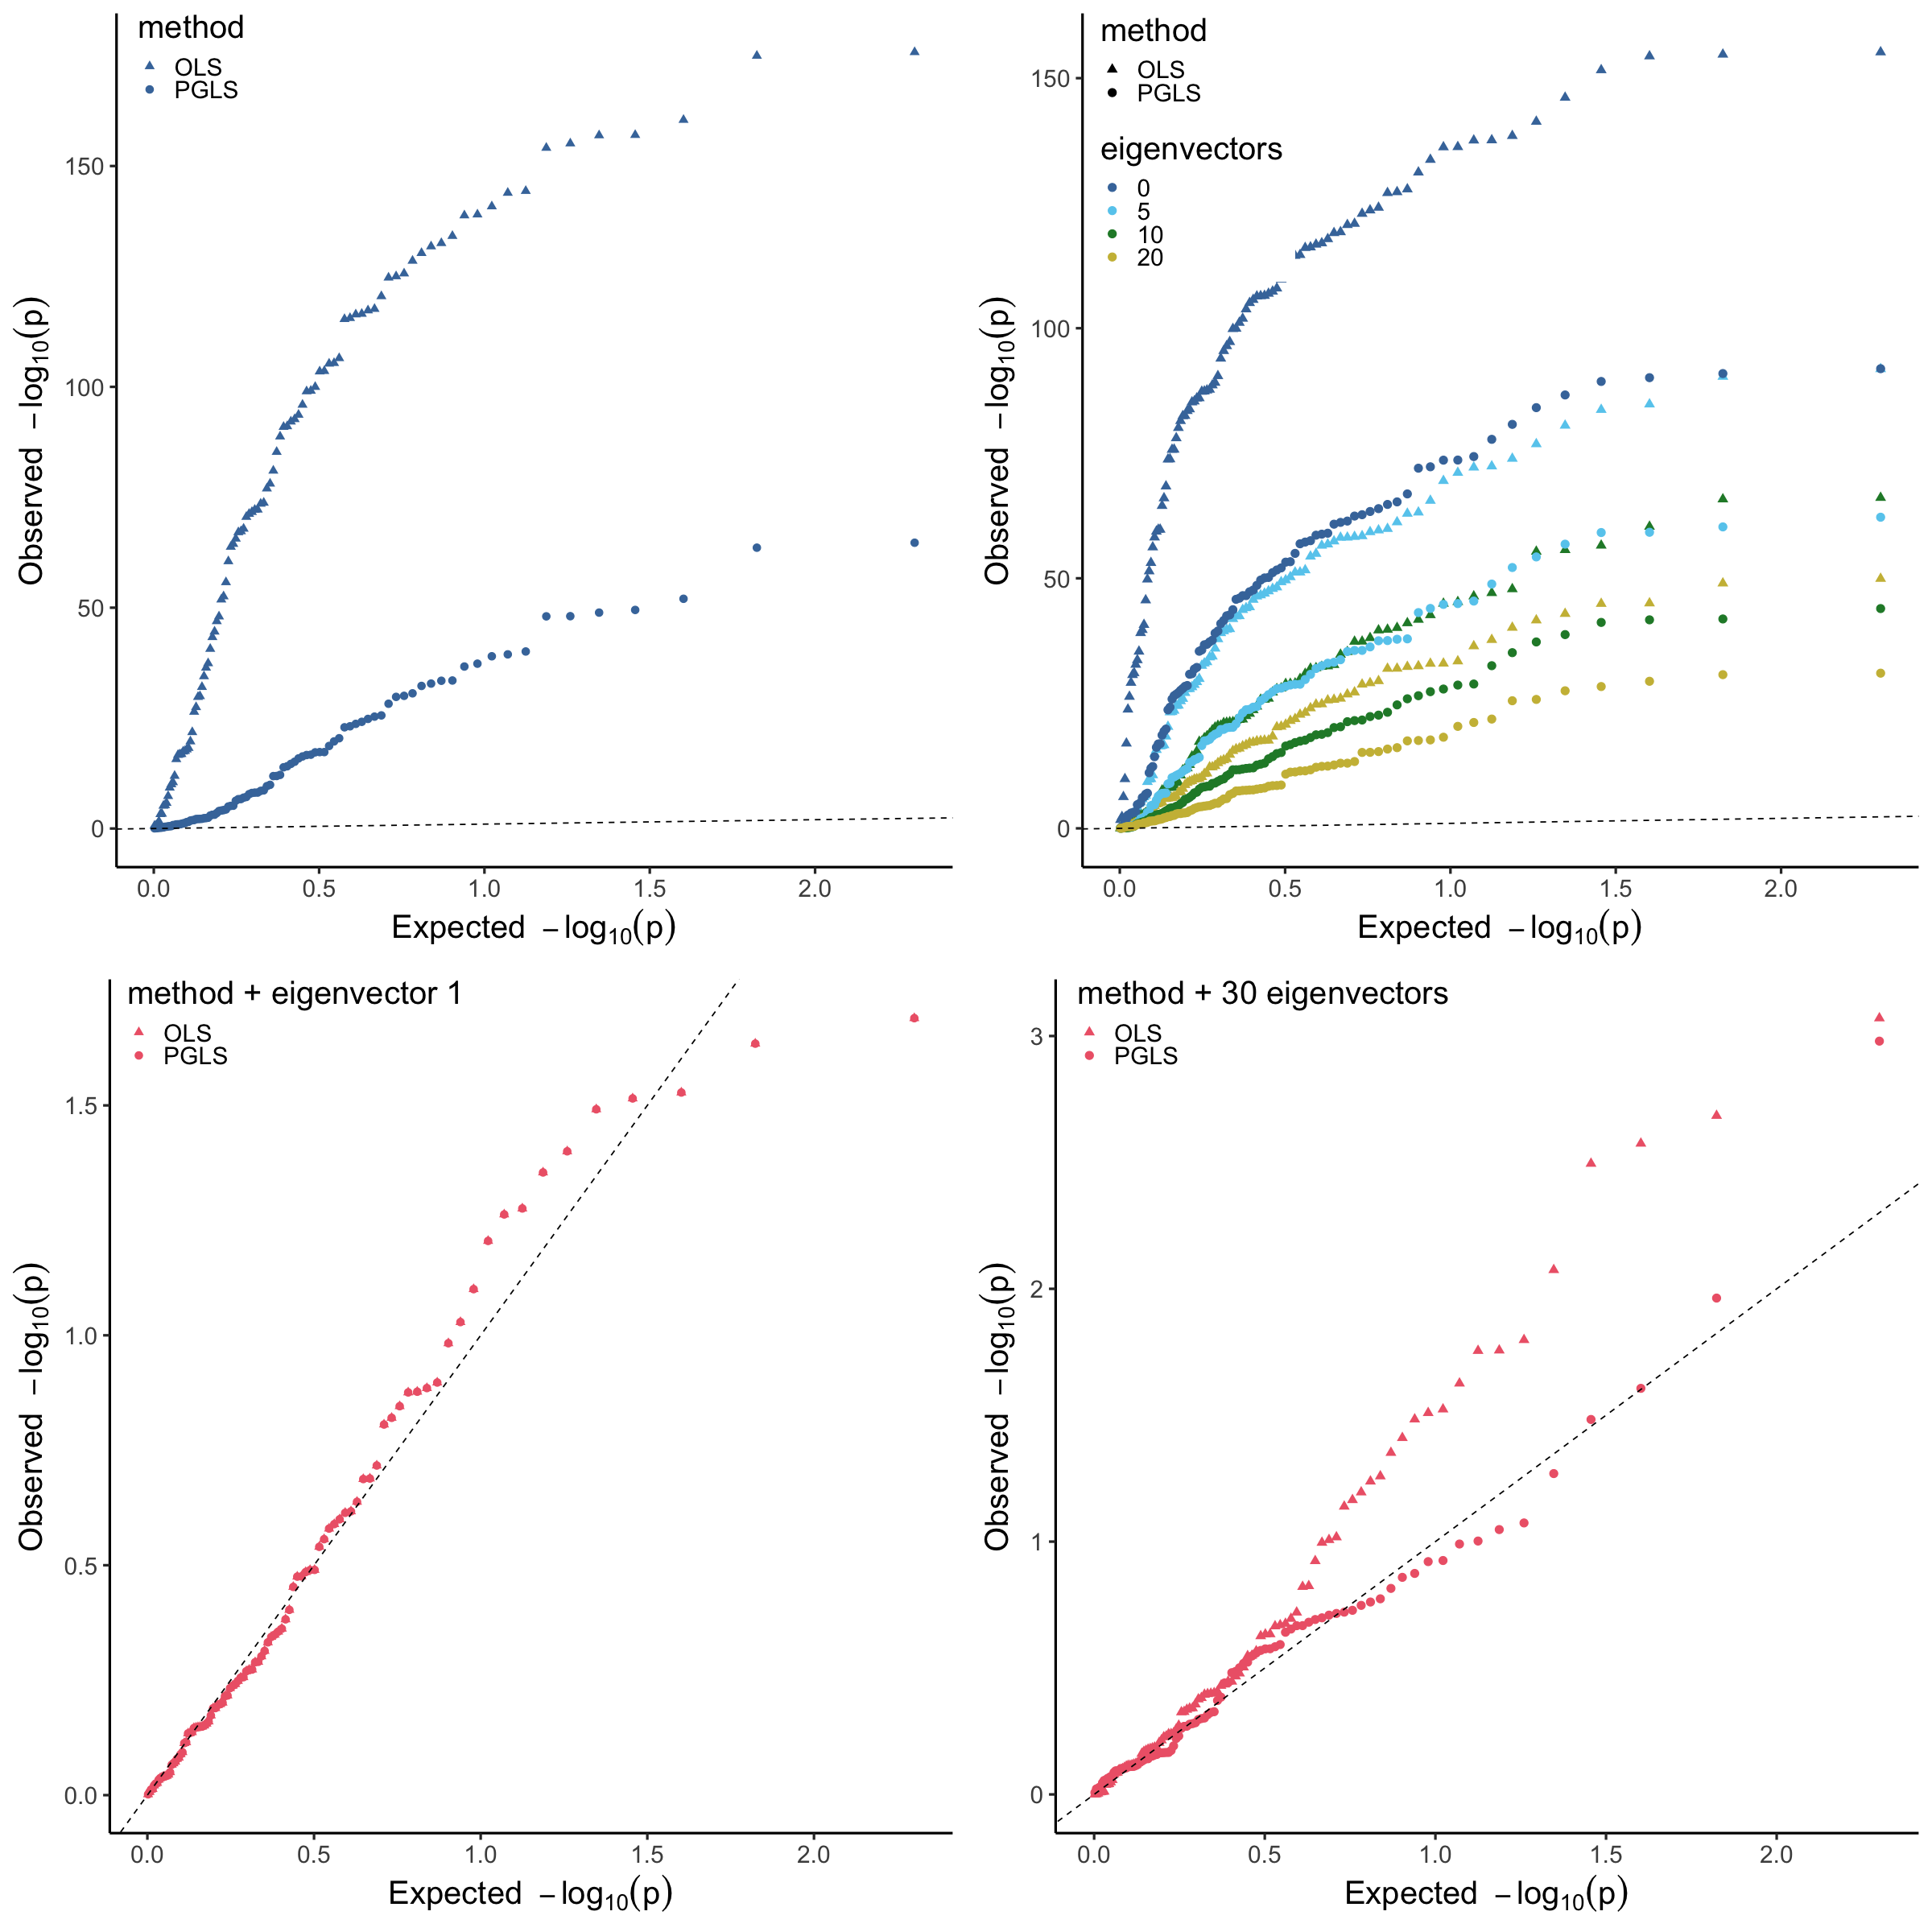

In [112]:
options(repr.plot.width = 20, repr.plot.height = 20)

row1 <- arrangeGrob(qq_plot_1, qq_plot_3, ncol = 2)
row2 <- arrangeGrob(qq_plot_2, qq_plot_4, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/Figure_3_raw.pdf", g, width = 20, height = 20)
ggsave("Figures_raw/Figure_3_raw.svg", g, width = 20, height = 20)

### Extra work

In [21]:
n_branches = length(yule_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = yule_tree$edge[i, 2]
    descendants = getDescendants(yule_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

sum_weights <- sum(yule_tree$edge.length)

branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- yule_tree$edge.length[1] / sum_weights
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- yule_tree$edge.length[i] / sum_weights
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df5 <- as.data.frame(VCVs_vec)
colnames(df5) <- paste0("VCV", 1:n_branches)

df5$VCV_tot <- rowSums(df5)
VCV_tot <- matrix(df5$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    Sigma = outer(PCs[,i], PCs[,i])
    name = Sigma_names[i]
    df5[[name]] = as.vector(Sigma)
}

In [22]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma21 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_21 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma22 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_22 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma23 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_23 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma24 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_24 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma25 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_25 <- as.vector(coeffs)

In [23]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma26 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_26 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma27 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_27 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma28 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_28 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma29 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_29 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma30 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)
model <- lm(cur_formula, data = df5)
coeffs <- coef(model)
# Numeric values for each edge
branch_values_yule_VCV_30 <- as.vector(coeffs)

In [24]:
# Create color mapping
n_colors <- 100
color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

value_max_21 <- max(abs(branch_values_yule_VCV_21))
color_breaks_21 <- seq(-value_max_21, value_max_21, length.out = n_colors)
value_max_22 <- max(abs(branch_values_yule_VCV_22))
color_breaks_22 <- seq(-value_max_22, value_max_22, length.out = n_colors)
value_max_23 <- max(abs(branch_values_yule_VCV_23))
color_breaks_23 <- seq(-value_max_23, value_max_23, length.out = n_colors)
value_max_24 <- max(abs(branch_values_yule_VCV_24))
color_breaks_24 <- seq(-value_max_24, value_max_24, length.out = n_colors)
value_max_25 <- max(abs(branch_values_yule_VCV_25))
color_breaks_25 <- seq(-value_max_25, value_max_25, length.out = n_colors)
value_max_26 <- max(abs(branch_values_yule_VCV_26))
color_breaks_26 <- seq(-value_max_26, value_max_26, length.out = n_colors)
value_max_27 <- max(abs(branch_values_yule_VCV_27))
color_breaks_27 <- seq(-value_max_27, value_max_27, length.out = n_colors)
value_max_28 <- max(abs(branch_values_yule_VCV_28))
color_breaks_28 <- seq(-value_max_28, value_max_28, length.out = n_colors)
value_max_29 <- max(abs(branch_values_yule_VCV_29))
color_breaks_29 <- seq(-value_max_29, value_max_29, length.out = n_colors)
value_max_30 <- max(abs(branch_values_yule_VCV_30))
color_breaks_30 <- seq(-value_max_30, value_max_30, length.out = n_colors)

In [25]:
# Assign colors to branches based on where each value falls in the scale
branch_colors_yule_VCV_21 <- color_palette[findInterval(branch_values_yule_VCV_21, 
                                                        color_breaks_21, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_22 <- color_palette[findInterval(branch_values_yule_VCV_22, 
                                                        color_breaks_22, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_23 <- color_palette[findInterval(branch_values_yule_VCV_23, 
                                                        color_breaks_23, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_24 <- color_palette[findInterval(branch_values_yule_VCV_24, 
                                                        color_breaks_24, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_25 <- color_palette[findInterval(branch_values_yule_VCV_25, 
                                                        color_breaks_25, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_26 <- color_palette[findInterval(branch_values_yule_VCV_26, 
                                                        color_breaks_26, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_27 <- color_palette[findInterval(branch_values_yule_VCV_27, 
                                                        color_breaks_27, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_28 <- color_palette[findInterval(branch_values_yule_VCV_28, 
                                                        color_breaks_28, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_29 <- color_palette[findInterval(branch_values_yule_VCV_29, 
                                                        color_breaks_29, 
                                                        all.inside = TRUE)]
branch_colors_yule_VCV_30 <- color_palette[findInterval(branch_values_yule_VCV_30, 
                                                        color_breaks_30, 
                                                        all.inside = TRUE)]

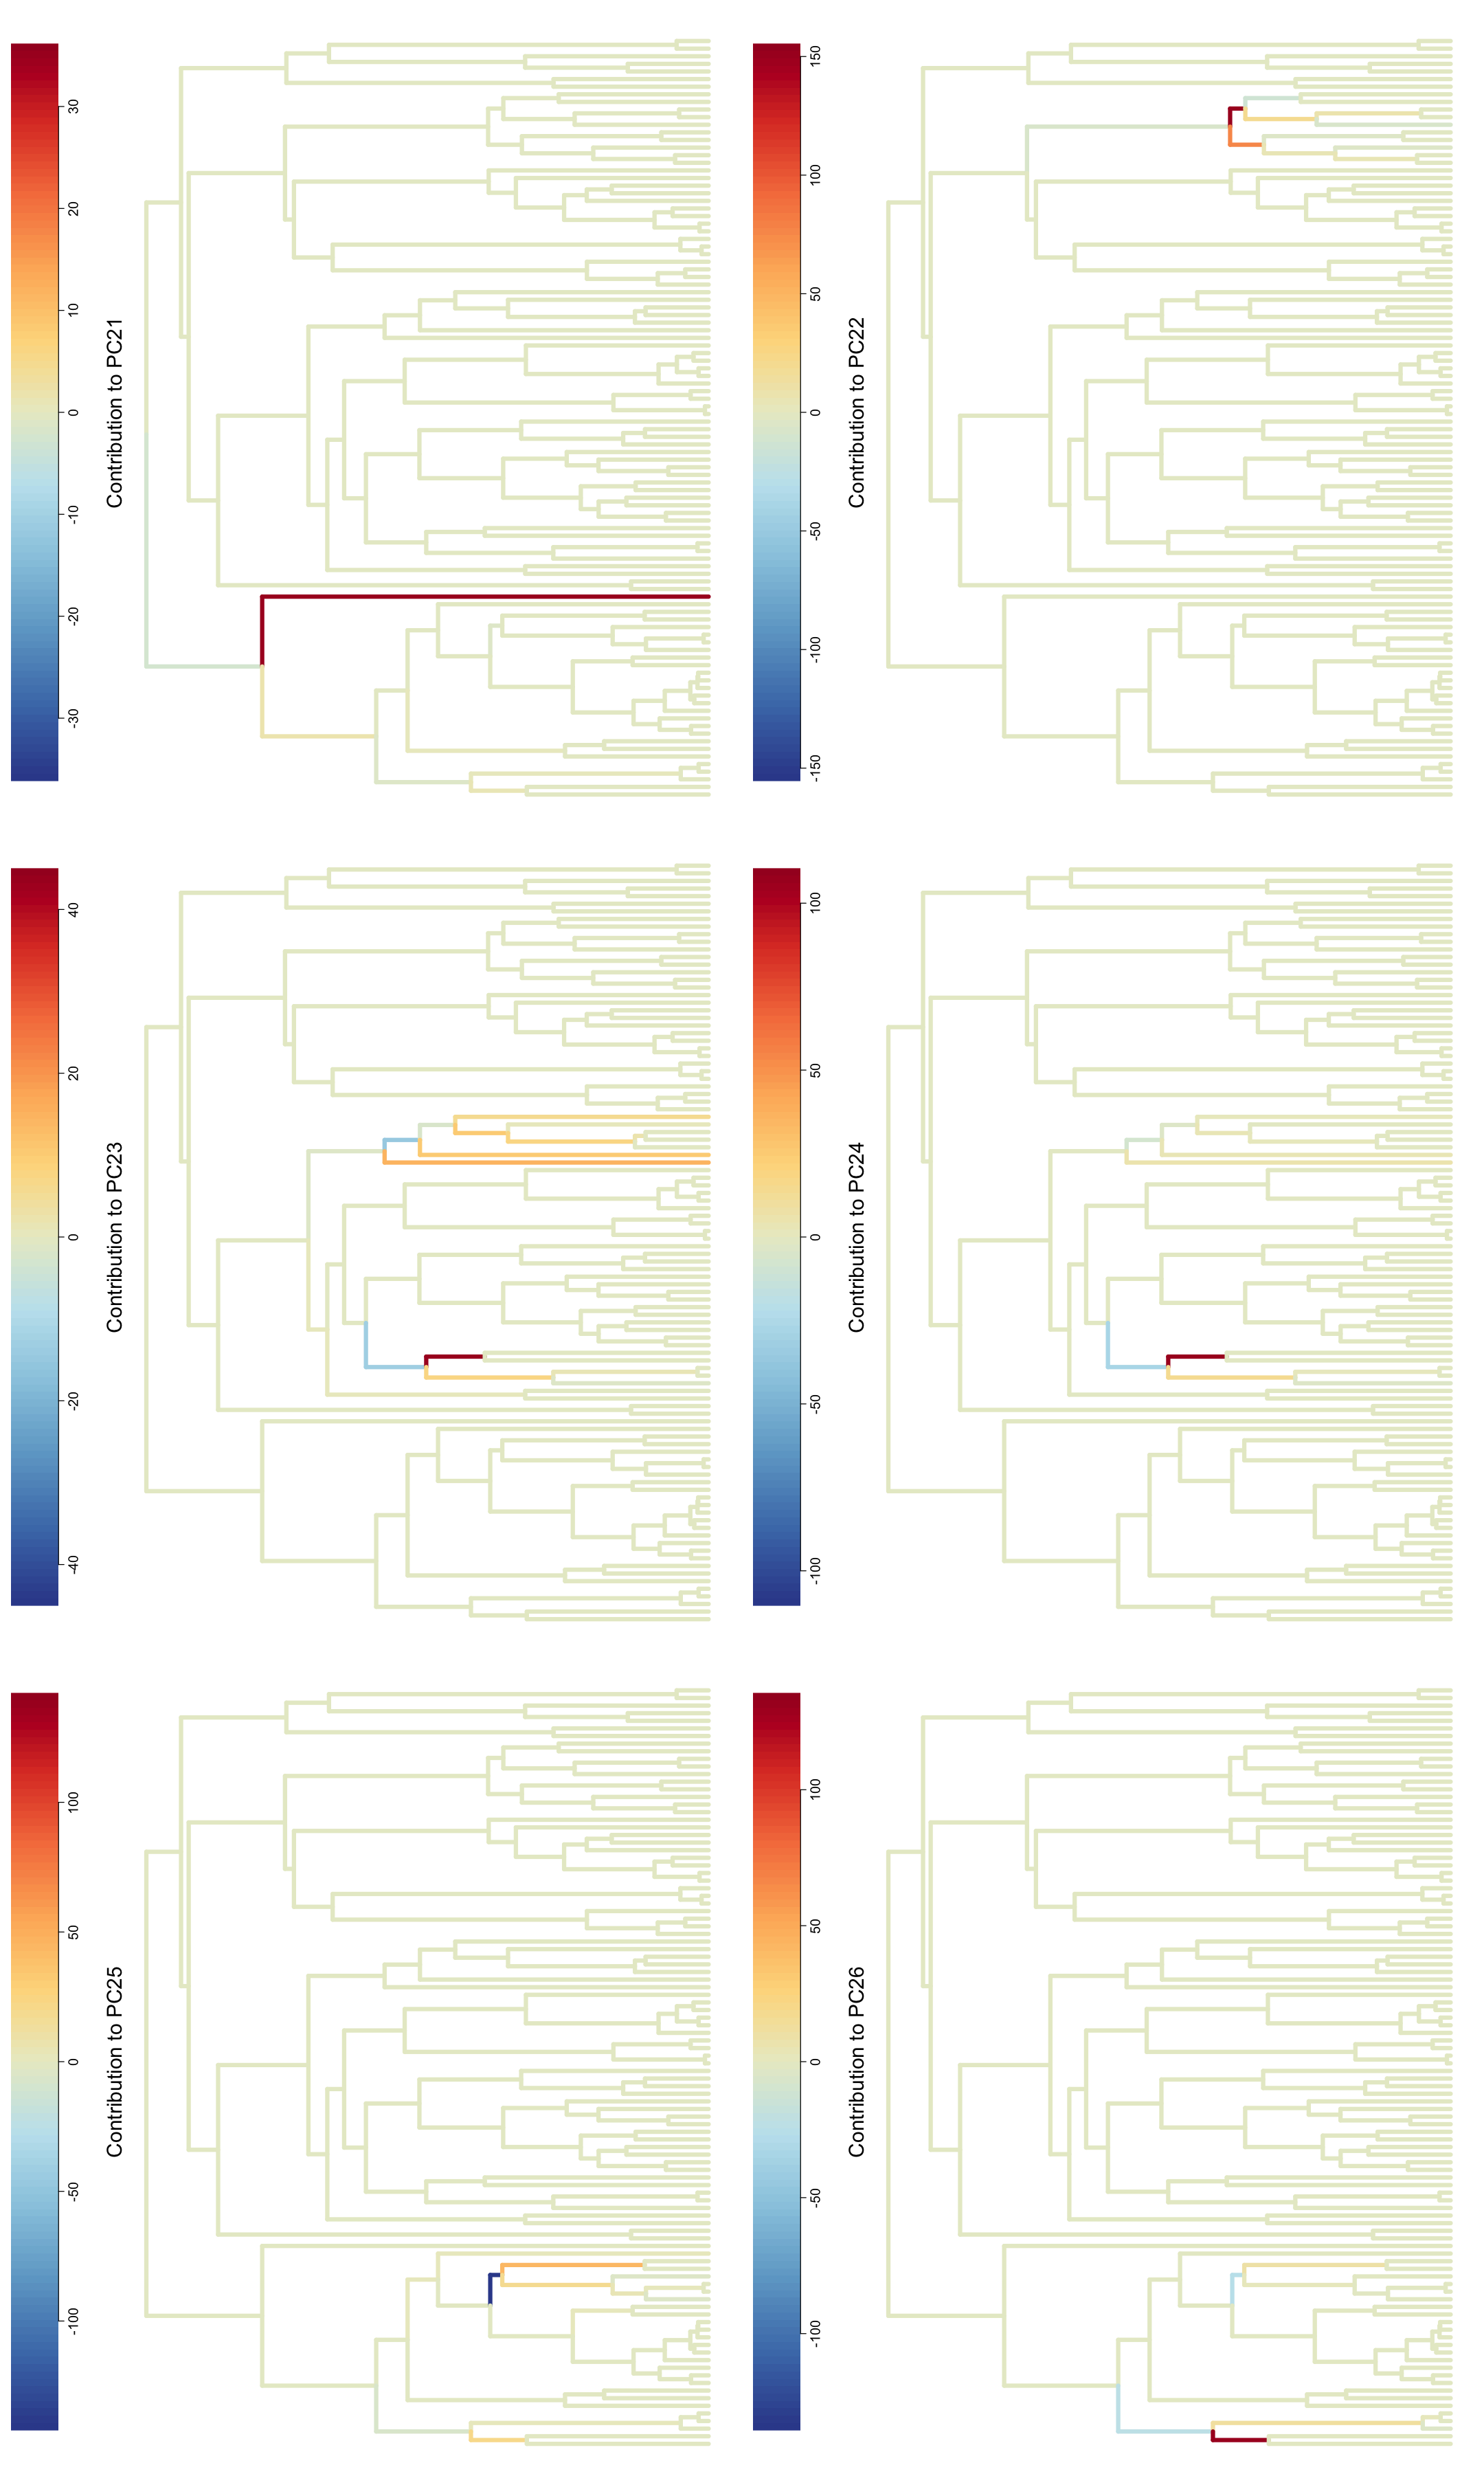

In [50]:
options(repr.plot.width = 18, repr.plot.height = 30)
layout(matrix(1:12, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_21, z = matrix(color_breaks_21, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC21", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_21, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_22, z = matrix(color_breaks_22, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC22", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_22, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_23, z = matrix(color_breaks_23, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC23", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_23, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_24, z = matrix(color_breaks_24, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC24", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_24, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_25, z = matrix(color_breaks_25, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC25", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_25, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_26, z = matrix(color_breaks_26, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC26", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_26, 
           edge.width = 5, show.tip.label = FALSE)

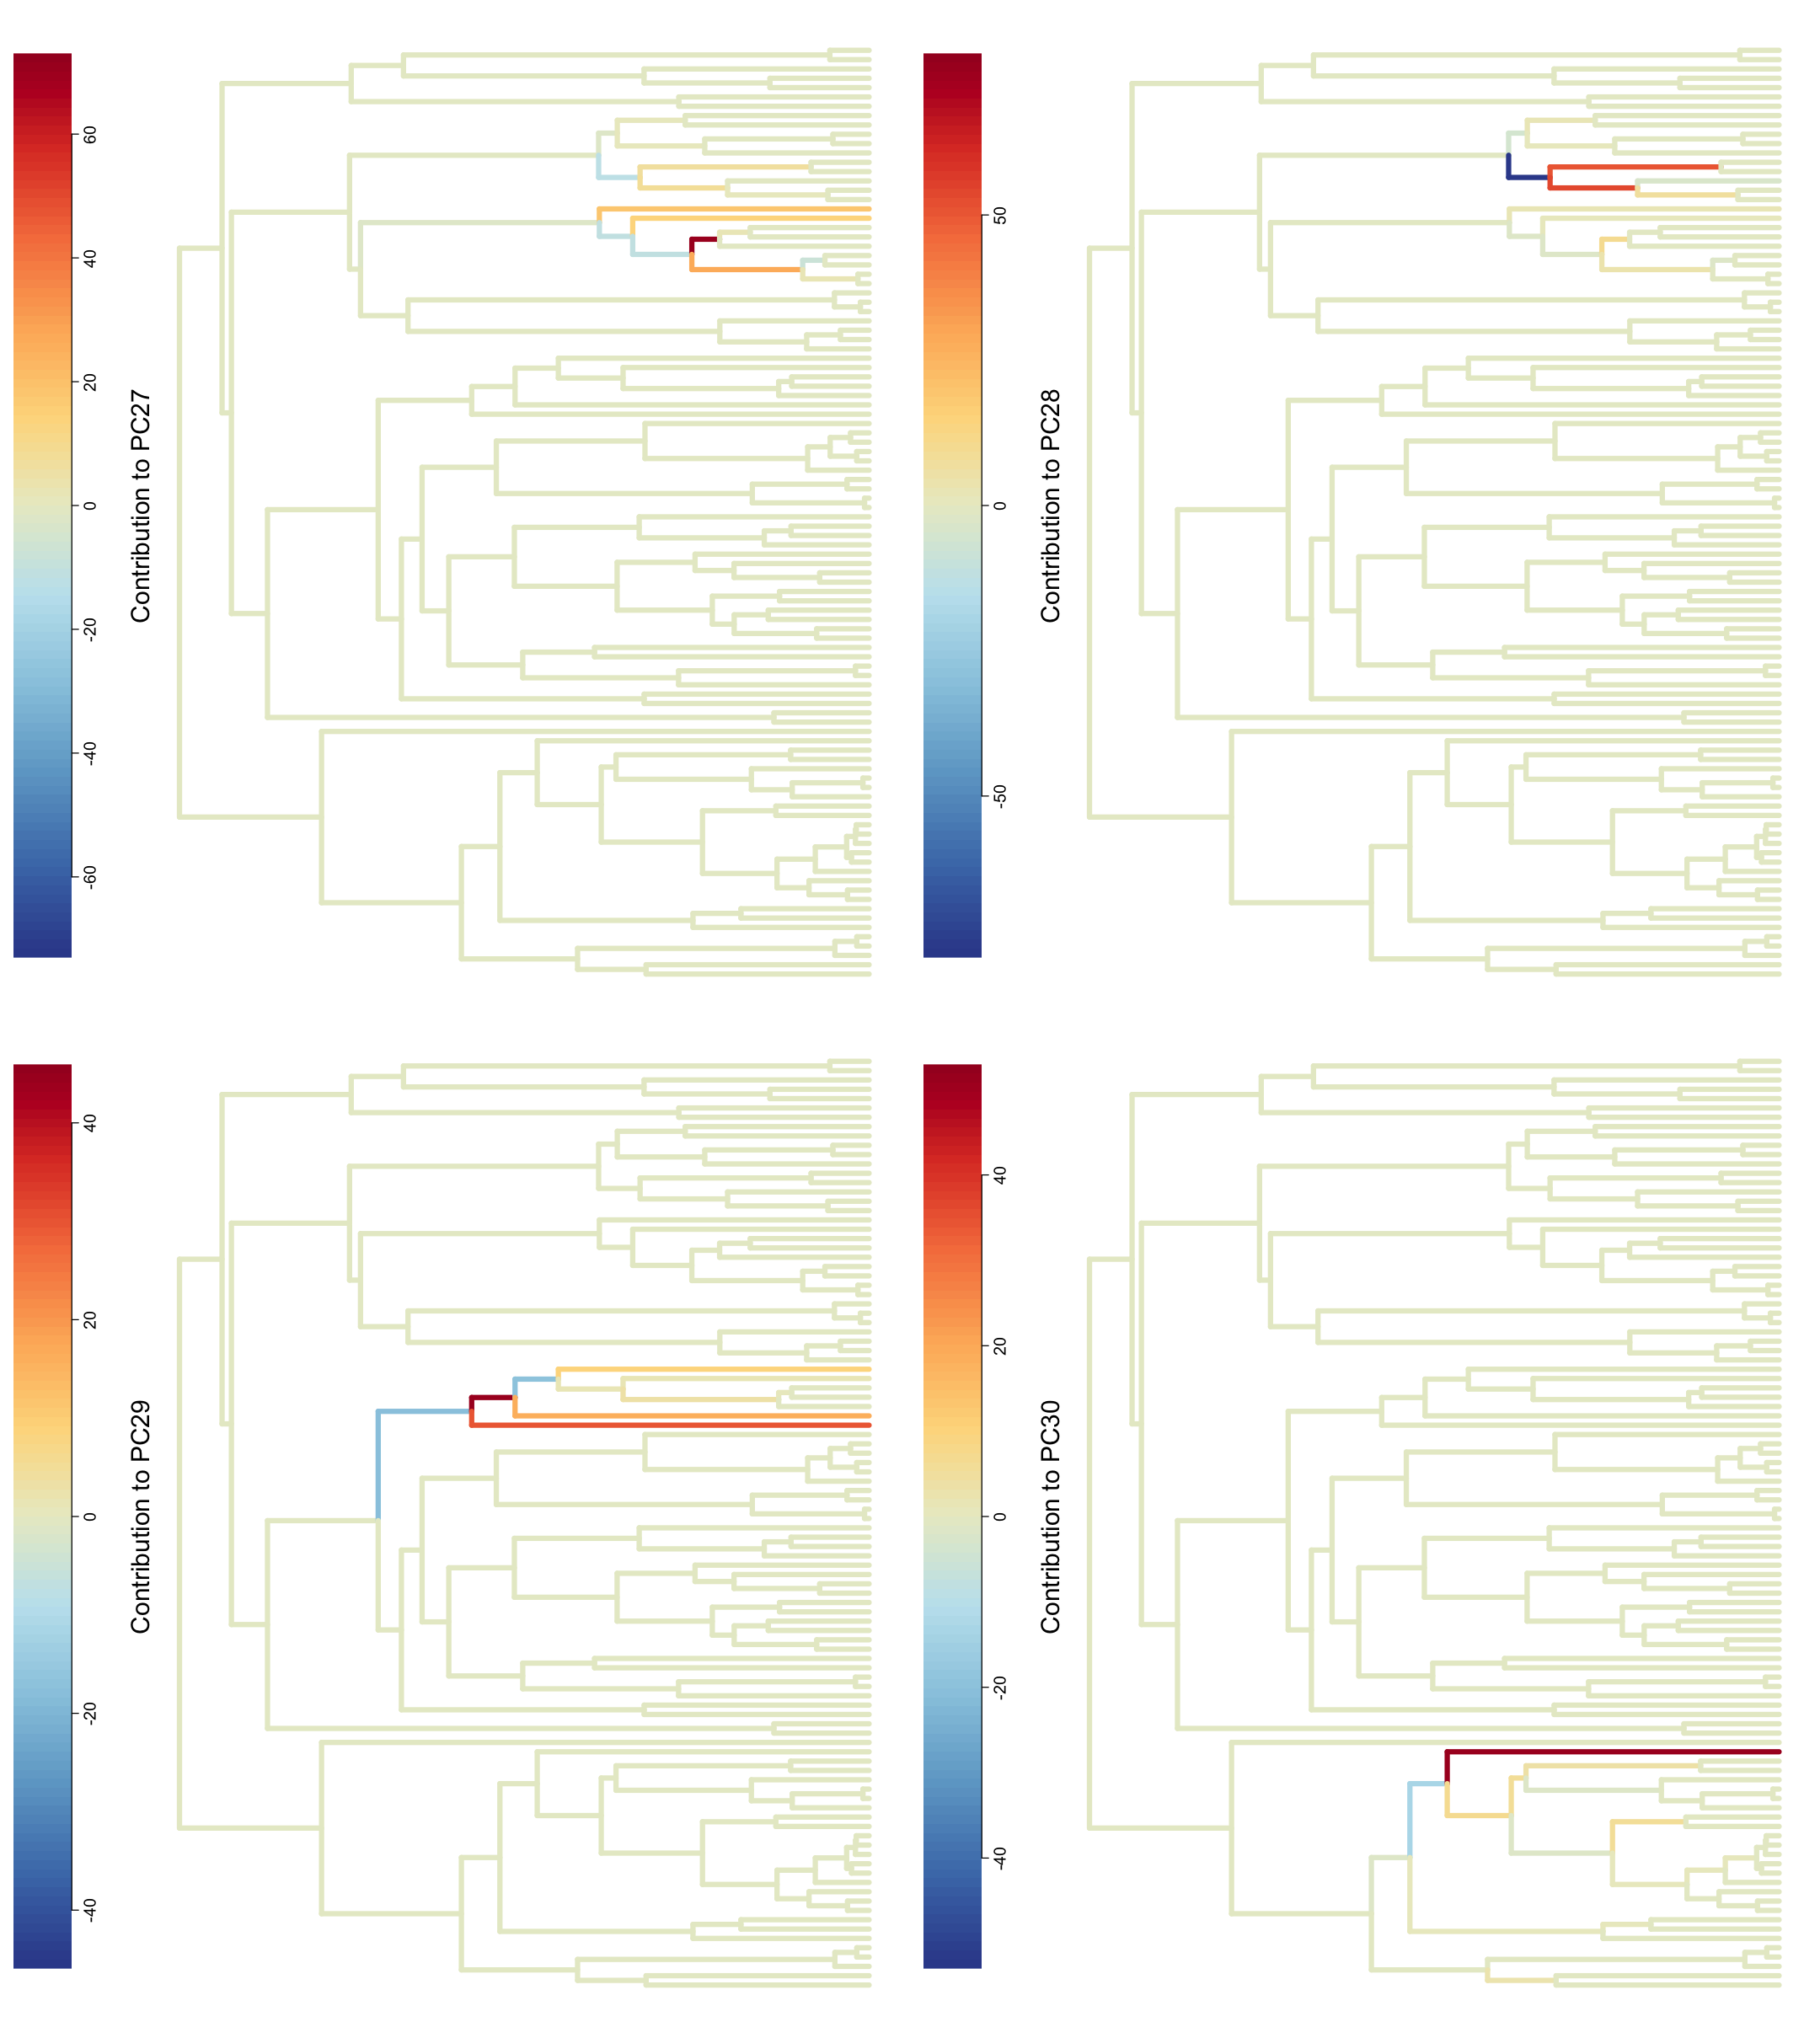

In [49]:
options(repr.plot.width = 18, repr.plot.height = 20)
layout(matrix(1:8, nrow = 2, byrow = TRUE), widths = c(3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_27, z = matrix(color_breaks_27, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC27", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_27, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_28, z = matrix(color_breaks_28, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC28", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_28, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_29, z = matrix(color_breaks_29, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC29", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_29, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_30, z = matrix(color_breaks_30, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to PC30", side = 4, line = 5, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_30, 
           edge.width = 5, show.tip.label = FALSE)